In [3]:
%pip install matplotlib seaborn numpy pandas

  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/4c/8c/290f021104741fea63769c31494f5324c0cd249bf536a65a4350767b1f22/matplotlib-3.10.9-cp311-cp311-macosx_10_12_x86_64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 912.6 kB/s eta 0:00:00 0:00:01
  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
  Obtaining dependency information for contourpy>=1.0.1 from https://files.pythonhosted.org/packages/91/2e/c4390a31919d8a78b90e8ecf87cd4b4c4f05a5b48d05ec17db8e5404c6f4/contourpy-1.3.3-cp311-cp311-macosx_10_9_x86_64.whl.metadata
  Obtaining dependency information for cycler>=0.10 from https://files.pythonhosted.org/packages/e7/05/c19819d5e3d95294a6f5947fb9b9629efb316b96de511b418c53d245aae6/cycler-0.12.1-py3-none-any.whl.metadata
  Obtaining dependency information for fonttools>=4.22

In [171]:
import pandas as pd
fam_hist_df = pd.read_csv("/Volumes/Elements/methylation-analysis/ppmi/condition/Family_History_24Nov2025.csv")

In [172]:
fam_hist_df.head()

,REC_ID,PATNO,EVENT_ID,PAG_NAME,INFODT,ANYFAMPD,BIOMOM,BIOMOMPD,BIODAD,BIODADPD,...,PATAUPD,KIDSNUM,KIDSPD,DISFAMPD,MATCOUS,MATCOUSPD,PATCOUS,PATCOUSPD,ORIG_ENTRY,LAST_UPDATE
0,269551601,3000,SC,FAMHXPD,01/2011,NaN,1,0.0,1.0,0.0,...,0.0,2.0,0.0,NaN,NaN,NaN,NaN,NaN,01/2011,2020-06-25 16:02:20.0
1,IA30932,3000,TRANS,FAMHXPD,05/2021,0.0,1,NaN,1.0,NaN,...,NaN,2.0,NaN,NaN,6.0,NaN,0.0,NaN,06/2021,2022-11-07 00:00:00.0
2,274798901,3001,SC,FAMHXPD,02/2011,NaN,1,0.0,1.0,0.0,...,0.0,3.0,0.0,NaN,NaN,NaN,NaN,NaN,02/2011,2020-06-25 16:04:31.0
3,IA30933,3001,TRANS,FAMHXPD,09/2021,0.0,1,NaN,1.0,NaN,...,NaN,3.0,NaN,NaN,7.0,NaN,6.0,NaN,01/2022,2022-11-07 00:00:00.0
4,733240301,3001,V15,FAMHXPD,03/2019,NaN,1,0.0,1.0,0.0,...,0.0,3.0,0.0,NaN,NaN,NaN,NaN,NaN,03/2019,2020-06-25 16:04:36.0


In [173]:
clean_fam_hist_df = fam_hist_df[fam_hist_df['ANYFAMPD'].notna()].copy()

In [174]:
print(f"Original shape: {fam_hist_df.shape}")
print(f"Cleaned shape: {clean_fam_hist_df.shape}")
print(f"Number of rows removed: {fam_hist_df.shape[0] - clean_fam_hist_df.shape[0]}")
print(f"Clean number of patient records: {clean_fam_hist_df['PATNO'].nunique()}")
print(f"Clean number of patient records with several records: {clean_fam_hist_df['PATNO'].value_counts().gt(1).sum()}")
print(f"Event-ID counts:\n{clean_fam_hist_df['EVENT_ID'].value_counts()}")

Original shape: (7683, 43)
Cleaned shape: (6728, 43)
Number of rows removed: 955
Clean number of patient records: 6220
Clean number of patient records with several records: 503
Event-ID counts:
EVENT_ID
SC       4520
TRANS     913
BL        731
LOG       557
V14         4
V13         2
V15         1
Name: count, dtype: int64


In [175]:
changed_patnos = (
    clean_fam_hist_df.groupby('PATNO')['ANYFAMPD']
    .nunique()
    .pipe(lambda s: s[s > 1].index)
)

subset = (
    clean_fam_hist_df[clean_fam_hist_df['PATNO'].isin(changed_patnos)]
    .sort_values(['PATNO', 'EVENT_ID'])
)

def summarise(g):
    # find rows where the value differs from the previous row
    mask = g['ANYFAMPD'] != g['ANYFAMPD'].shift()
    mask.iloc[0] = False  # skip the first row (no prior value)
    transitions = g[mask]
    prev_values = g['ANYFAMPD'].shift()[mask]
    prev_event_ids = g['EVENT_ID'].shift()[mask]
    return pd.DataFrame({
        'from_EVENT_ID': prev_event_ids.values,
        'from': prev_values.values,
        'to_EVENT_ID': transitions['EVENT_ID'].values,
        'to': transitions['ANYFAMPD'].values,
    })

changed_detail = (
    subset.groupby('PATNO', group_keys=False)
    .apply(summarise)
    .reset_index(level=0)
    .rename(columns={'level_0': 'PATNO'})
    .reset_index(drop=True)
)

print(f"PATNOs where ANYFAMPD changed value: {len(changed_patnos)}\n")
print(changed_detail.to_string(index=False))

PATNOs where ANYFAMPD changed value: 40

 index from_EVENT_ID  from to_EVENT_ID  to
     0            SC   1.0       TRANS 0.0
     1         TRANS   0.0         V15 1.0
     0            SC   1.0       TRANS 0.0
     0            SC   1.0       TRANS 0.0
     0            SC   1.0       TRANS 0.0
     0            SC   1.0       TRANS 0.0
     0            SC   1.0       TRANS 0.0
     0            SC   1.0       TRANS 0.0
     0            SC   1.0       TRANS 0.0
     0            SC   1.0       TRANS 0.0
     0            SC   1.0       TRANS 0.0
     0            SC   1.0       TRANS 0.0
     0            SC   1.0       TRANS 0.0
     0            SC   1.0       TRANS 0.0
     0            SC   1.0       TRANS 0.0
     0            SC   1.0       TRANS 0.0
     0            SC   1.0       TRANS 0.0
     0            SC   1.0       TRANS 0.0
     0            SC   1.0       TRANS 0.0
     0            SC   1.0       TRANS 0.0
     0            SC   1.0       TRANS 0.0
     0       

In [176]:
# Identify PATNOs that occur multiple times vs once
patno_counts = clean_fam_hist_df['PATNO'].value_counts()
multi_patno = patno_counts[patno_counts > 1].index
single_patno = patno_counts[patno_counts == 1].index

# For multi-occurrence PATNOs, keep only the TRANS event row
trans_rows = clean_fam_hist_df[
    (clean_fam_hist_df['PATNO'].isin(multi_patno)) & 
    (clean_fam_hist_df['EVENT_ID'] == 'TRANS')
]

# For single-occurrence PATNOs, keep the row as is
single_rows = clean_fam_hist_df[clean_fam_hist_df['PATNO'].isin(single_patno)]

# Combine and update clean_fam_hist_df so each PATNO appears only once
clean_fam_hist_df = pd.concat([trans_rows, single_rows], ignore_index=True).sort_values('PATNO').reset_index(drop=True)

print(f"Shape after filtering to one row per PATNO: {clean_fam_hist_df.shape}")
print(f"Unique PATNOs: {clean_fam_hist_df['PATNO'].nunique()}")
print(f"All PATNOs appear exactly once: {(clean_fam_hist_df['PATNO'].value_counts() == 1).all()}")
print(f"\nRows kept from multi-PATNO (TRANS events): {len(trans_rows)}")
print(f"Rows kept from single-PATNO: {len(single_rows)}")

Shape after filtering to one row per PATNO: (6219, 43)
Unique PATNOs: 6219
All PATNOs appear exactly once: True

Rows kept from multi-PATNO (TRANS events): 502
Rows kept from single-PATNO: 5717


In [177]:
participant_status_df = pd.read_csv("/Volumes/Elements/methylation-analysis/ppmi/Participant_Status_24Nov2025.csv")

In [178]:
participant_status_df.head()

,PATNO,COHORT,COHORT_DEFINITION,ENROLL_DATE,ENROLL_STATUS,STATUS_DATE,SCREENEDAM,ENROLL_AGE,INEXPAGE,AV133STDY,...,ENRLPINK1,ENRLPRKN,ENRLSRDC,ENRLNORM,ENRLOTHGV,ENRLHPSM,ENRLRBD,ENRLLRRK2,ENRLSNCA,ENRLGBA
0,3000,2,Healthy Control,02/2011,Withdrew,10/2024,NaN,69.1,NaN,0.0,...,0.0,0.0,0.0,NaN,NaN,0,0,0,0,0
1,3001,1,Parkinson's Disease,03/2011,Enrolled,09/2021,NaN,65.1,NaN,0.0,...,0.0,0.0,1.0,NaN,NaN,0,0,0,0,0
2,3002,1,Parkinson's Disease,03/2011,Withdrew,10/2024,NaN,67.6,NaN,0.0,...,0.0,0.0,1.0,NaN,NaN,0,0,0,0,0
3,3003,1,Parkinson's Disease,04/2011,Enrolled,01/2022,NaN,56.7,NaN,0.0,...,0.0,0.0,1.0,NaN,NaN,0,0,0,0,0
4,3004,2,Healthy Control,04/2011,Enrolled,01/2022,NaN,59.4,NaN,0.0,...,0.0,0.0,0.0,NaN,NaN,0,0,0,0,0


In [179]:
clean_fam_hist_status_df = clean_fam_hist_df.merge(participant_status_df, on="PATNO", how="left")

In [145]:
print(f"Participant status counts:\n{clean_fam_hist_status_df['ENROLL_STATUS'].value_counts()}")

Participant status counts:
ENROLL_STATUS
Enrolled             3574
Screen failed        1784
Withdrew              326
Screened              126
Excluded               90
Pending                84
Withdraw Deceased      69
Baseline Withdraw      43
Complete               41
Screen Scheduled       29
Baseline               27
Declined               22
LP Eligible             3
DAT scheduled           1
Name: count, dtype: int64


In [180]:
clean_fam_hist_df = clean_fam_hist_status_df[~clean_fam_hist_status_df['ENROLL_STATUS'].isin(['Screen failed', 'Withdrew', 'Withdrew Deceased', 'Baseline Withdraw', 'Excluded'])]

In [181]:
print(f"Participants after removing excluded statuses:\n{clean_fam_hist_df['ENROLL_STATUS'].value_counts()} ")
print(f"Final number of patient records: {clean_fam_hist_df['PATNO'].nunique()}")
print(f"Numbers per cohort definition:\n{clean_fam_hist_df['COHORT_DEFINITION'].value_counts()}")

Participants after removing excluded statuses:
ENROLL_STATUS
Enrolled             3574
Screened              126
Pending                84
Withdraw Deceased      69
Complete               41
Screen Scheduled       29
Baseline               27
Declined               22
LP Eligible             3
DAT scheduled           1
Name: count, dtype: int64 
Final number of patient records: 3976
Numbers per cohort definition:
COHORT_DEFINITION
Prodromal              2598
Parkinson's Disease    1135
Healthy Control         220
SWEDD                    23
Name: count, dtype: int64


In [204]:
clean_fam_hist_df['PATNO'].nunique()
# 3976

3976

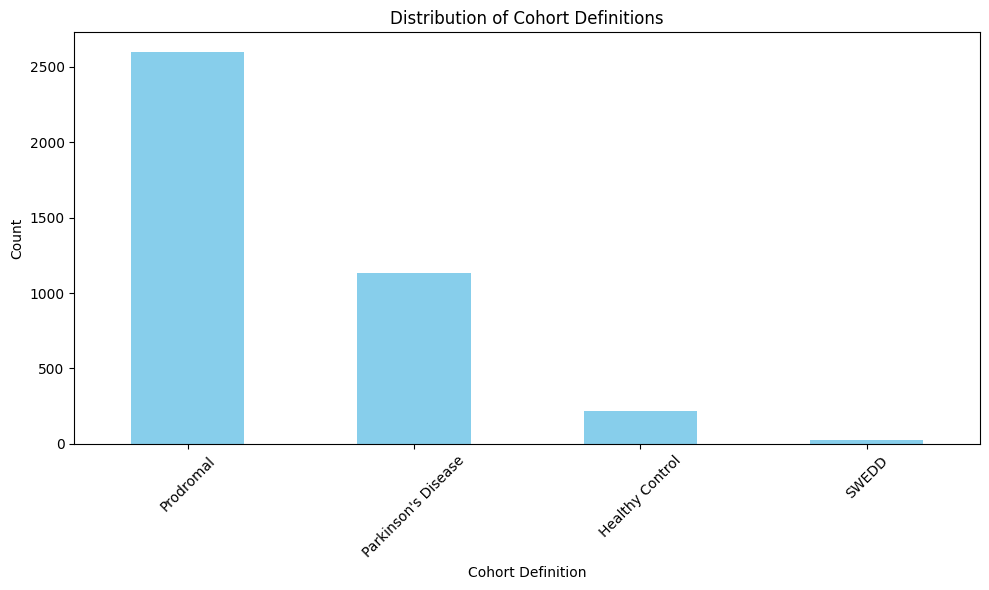

In [182]:
import matplotlib.pyplot as plt

# Plotting the distribution of cohort definitions
plt.figure(figsize=(10, 6))
clean_fam_hist_df['COHORT_DEFINITION'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Cohort Definitions')
plt.xlabel('Cohort Definition')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [183]:
gen_cond = pd.DataFrame(columns=['PATNO', 'GEN_COND'])
for row in clean_fam_hist_df.itertuples():
    if row.ENRLPINK1 == 1:
        gen_cond = pd.concat([gen_cond, pd.DataFrame([{'PATNO': row.PATNO, 'GEN_COND': 'PINK1'}])], ignore_index=True)
    elif row.ENRLPRKN == 1:
        gen_cond = pd.concat([gen_cond, pd.DataFrame([{'PATNO': row.PATNO, 'GEN_COND': 'PRKN'}])], ignore_index=True)
    elif row.ENRLLRRK2 == 1:
        gen_cond = pd.concat([gen_cond, pd.DataFrame([{'PATNO': row.PATNO, 'GEN_COND': 'LRRK2'}])], ignore_index=True)
    elif row.ENRLSNCA == 1:
        gen_cond = pd.concat([gen_cond, pd.DataFrame([{'PATNO': row.PATNO, 'GEN_COND': 'SNCA'}])], ignore_index=True)
    elif row.ENRLGBA == 1:
        gen_cond = pd.concat([gen_cond, pd.DataFrame([{'PATNO': row.PATNO, 'GEN_COND': 'GBA'}])], ignore_index=True)
    elif row.ENRLSRDC == 1:
        gen_cond = pd.concat([gen_cond, pd.DataFrame([{'PATNO': row.PATNO, 'GEN_COND': 'SRDC'}])], ignore_index=True)
    else:
        gen_cond = pd.concat([gen_cond, pd.DataFrame([{'PATNO': row.PATNO, 'GEN_COND': 'N/A'}])], ignore_index=True)

olfactory_cond = pd.DataFrame(columns=['PATNO', 'OLF_COND'])
for row in clean_fam_hist_df.itertuples():
    if row.ENRLHPSM == 1:
        olfactory_cond = pd.concat([olfactory_cond, pd.DataFrame([{'PATNO': row.PATNO, 'OLF_COND': 'hyposmia'}])], ignore_index=True)
    elif row.ENRLNORM == 1:
        olfactory_cond = pd.concat([olfactory_cond, pd.DataFrame([{'PATNO': row.PATNO, 'OLF_COND': 'normosmia'}])], ignore_index=True)
    else:
        olfactory_cond = pd.concat([olfactory_cond, pd.DataFrame([{'PATNO': row.PATNO, 'OLF_COND': 'N/A'}])], ignore_index=True)

clean_fam_hist_df = clean_fam_hist_df.merge(gen_cond, on='PATNO', how='left')
clean_fam_hist_df = clean_fam_hist_df.merge(olfactory_cond, on='PATNO', how='left')
    

In [184]:
clean_fam_hist_df[clean_fam_hist_df['ANYFAMPD'] == 0]


,REC_ID,PATNO,EVENT_ID,PAG_NAME,INFODT,ANYFAMPD,BIOMOM,BIOMOMPD,BIODAD,BIODADPD,...,ENRLSRDC,ENRLNORM,ENRLOTHGV,ENRLHPSM,ENRLRBD,ENRLLRRK2,ENRLSNCA,ENRLGBA,GEN_COND,OLF_COND
0,IA30933,3001,TRANS,FAMHXPD,09/2021,0.0,1,NaN,1.0,NaN,...,1.0,NaN,NaN,0,0,0,0,0,SRDC,N/A
1,IA30935,3003,TRANS,FAMHXPD,12/2021,0.0,1,NaN,1.0,NaN,...,1.0,NaN,NaN,0,0,0,0,0,SRDC,N/A
2,IA30936,3004,TRANS,FAMHXPD,01/2022,0.0,1,NaN,1.0,NaN,...,0.0,NaN,NaN,0,0,0,0,0,N/A,N/A
3,IA30938,3009,TRANS,FAMHXPD,05/2021,0.0,1,NaN,1.0,NaN,...,0.0,NaN,NaN,0,0,0,0,0,N/A,N/A
4,IA30939,3010,TRANS,FAMHXPD,05/2021,0.0,1,NaN,1.0,NaN,...,1.0,NaN,NaN,0,0,0,0,0,SRDC,N/A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3968,IA845925,534071,SC,FAMHXPD,10/2025,0.0,1,NaN,1.0,NaN,...,0.0,0.0,0.0,1,0,0,0,0,N/A,hyposmia
3969,IA884239,538968,SC,FAMHXPD,11/2025,0.0,1,NaN,1.0,NaN,...,0.0,0.0,0.0,1,0,0,0,0,N/A,hyposmia
3970,IA871745,541964,SC,FAMHXPD,10/2025,0.0,1,NaN,1.0,NaN,...,0.0,0.0,1.0,0,0,0,0,1,GBA,N/A
3971,IA872802,542315,SC,FAMHXPD,11/2025,0.0,1,NaN,1.0,NaN,...,0.0,0.0,0.0,1,0,0,0,0,N/A,hyposmia


### What's the distribution of diagnosed participants having family members with PD per genetic group?

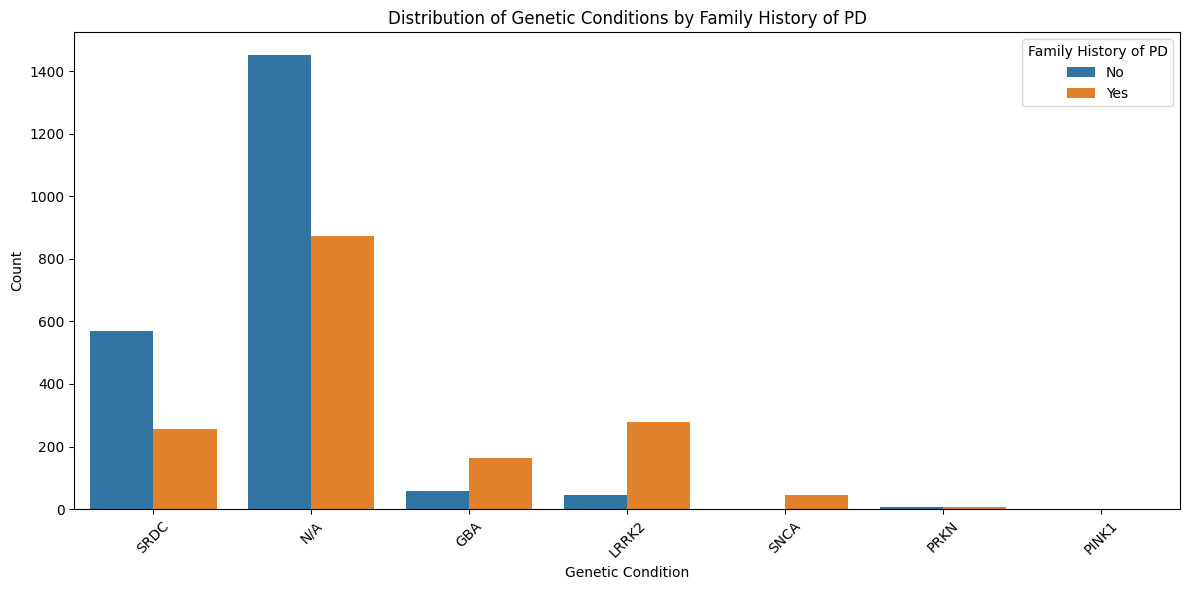

In [185]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plot_df = clean_fam_hist_df[clean_fam_hist_df['COHORT'] != 2].copy()
plot_df['ANYFAMPD'] = plot_df['ANYFAMPD'].map({0: 'No', 1: 'Yes'})

plt.figure(figsize=(12, 6))
sns.countplot(data=plot_df, x='GEN_COND', hue='ANYFAMPD', hue_order=['No', 'Yes'])
plt.title('Distribution of Genetic Conditions by Family History of PD')
plt.xlabel('Genetic Condition')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Family History of PD')
plt.tight_layout()
plt.show()

#### Are there participants in the case cohorts carrying more than one mutation?

In [186]:
mutation_cols = [
    'ENRLPINK1',
    'ENRLPRKN',
    'ENRLLRRK2',
    'ENRLSNCA',
    'ENRLGBA',
    'ENRLSRDC',
]

multi_mut_patnos = (
    plot_df.assign(n_mutations=plot_df[mutation_cols].sum(axis=1))
    .loc[lambda d: d['n_mutations'] > 1, ['PATNO', 'n_mutations'] + mutation_cols]
    .sort_values(['n_mutations', 'PATNO'], ascending=[False, True])
)

print(f"PATNO rows with >1 mutation flag set to 1: {len(multi_mut_patnos)}")
print(f"Unique PATNOs with >1 mutation flag: {multi_mut_patnos['PATNO'].nunique()}")
multi_mut_patnos

PATNO rows with >1 mutation flag set to 1: 2
Unique PATNOs with >1 mutation flag: 2


,PATNO,n_mutations,ENRLPINK1,ENRLPRKN,ENRLLRRK2,ENRLSNCA,ENRLGBA,ENRLSRDC
1324,141081,4.0,0.0,1.0,1,1,1,0.0
1308,140041,2.0,0.0,0.0,1,0,1,0.0


### Are there participants from the control cohort having relatives with PD?

In [187]:
clean_fam_hist_df[clean_fam_hist_df['COHORT'] == 2]["ANYFAMPD"].value_counts()

ANYFAMPD
0.0    199
1.0     21
Name: count, dtype: int64

**Further above** participants were identified who show up with more than one mutation in genes known to be involved in PD. I think those do not make any sense and given the small number (2) the respective samples will be removed rather than invetigated upon to make sense out of them.

In [188]:
clean_fam_hist_df = clean_fam_hist_df[~clean_fam_hist_df['PATNO'].isin(['141081', '140041'])]

### Calculate the age when first diagnosed

In [189]:
diag_hist = pd.read_csv("/Volumes/Elements/methylation-analysis/ppmi/condition/PD_Diagnosis_History_24Nov2025.csv")

In [190]:
clean_fam_hist_df = clean_fam_hist_df.merge(diag_hist[['PATNO', 'PDDXDT']], on='PATNO', how='left')

In [192]:
# ENROLL_DATE - PDDXDT = years since diagnosis at enrollment
# ENRLL_AGE - (ENROLL_DATE - PDDXDT) = age at diagnosis

clean_fam_hist_df['AGE_AT_DX'] = round(clean_fam_hist_df['ENROLL_AGE'] - (pd.to_datetime(clean_fam_hist_df['ENROLL_DATE']) - pd.to_datetime(clean_fam_hist_df['PDDXDT'])).dt.days / 365.25, 2)

/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_37215/2095973780.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  clean_fam_hist_df['AGE_AT_DX'] = round(clean_fam_hist_df['ENROLL_AGE'] - (pd.to_datetime(clean_fam_hist_df['ENROLL_DATE']) - pd.to_datetime(clean_fam_hist_df['PDDXDT'])).dt.days / 365.25, 2)
/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_37215/2095973780.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  clean_fam_hist_df['AGE_AT_DX'] = round(clean_fam_hist_df['ENROLL_AGE'] - (pd.to_datetime(clean_fam_hist_df['ENROLL_DATE']) - pd.to_datetime(clean_fam_hist_df['PDDXDT'])).dt.days / 365.25, 2)


In [193]:
clean_fam_hist_df.groupby('GEN_COND')['AGE_AT_DX'].describe()

,count,mean,std,min,25%,50%,75%,max
GEN_COND,,,,,,,,
GBA,56.0,58.510536,9.825432,38.55,52.725,58.335,66.1575,75.78
LRRK2,126.0,60.609444,8.811590,31.60,55.695,61.280,66.9200,80.00
N/A,77.0,62.689610,9.884958,32.32,57.270,63.790,69.4000,81.63
PINK1,1.0,39.780000,NaN,39.78,39.780,39.780,39.7800,39.78
PRKN,14.0,45.591429,10.172425,29.38,36.800,44.720,53.3175,61.98
SNCA,34.0,47.232941,10.494243,28.20,40.815,46.570,52.3525,76.53
SRDC,822.0,62.379027,9.316019,30.80,56.270,63.090,69.0500,84.82


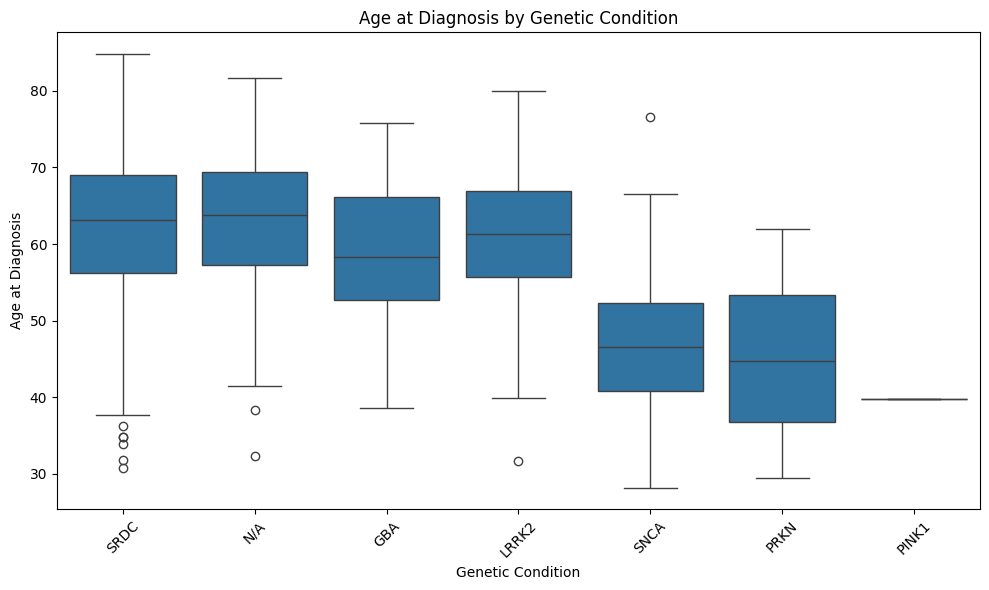

In [194]:
boxplot_df = clean_fam_hist_df[clean_fam_hist_df['AGE_AT_DX'].notna()]
plt.figure(figsize=(10, 6))
sns.boxplot(data=boxplot_df, x='GEN_COND', y='AGE_AT_DX')
plt.title('Age at Diagnosis by Genetic Condition')
plt.xlabel('Genetic Condition')
plt.ylabel('Age at Diagnosis')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### What is the distribution of phenotype features across the genetic groups?

In [196]:
# ENRLHPSM
# ENRLRBD
# ENRLNORM

clean_fam_hist_df['OLF_COND'].value_counts()

OLF_COND
N/A          2080
hyposmia     1844
normosmia      52
Name: count, dtype: int64

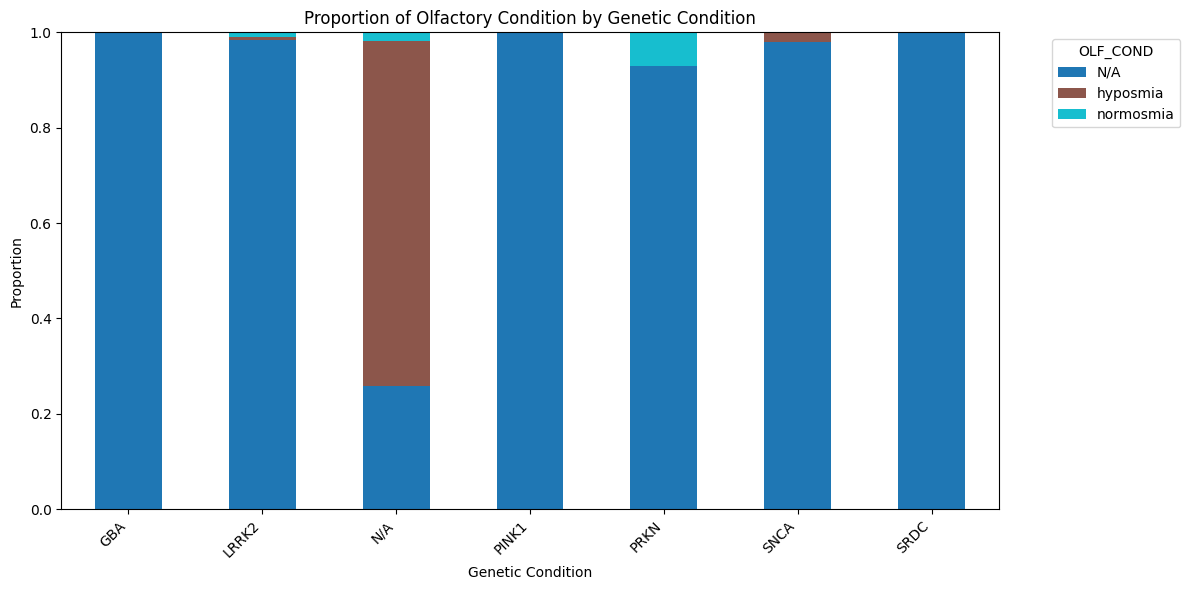

In [197]:
prop_df = (
    clean_fam_hist_df.groupby(['GEN_COND', 'OLF_COND'])
    .size()
    .groupby(level=0)
    .transform(lambda x: x / x.sum())
    .unstack('OLF_COND', fill_value=0)
)

ax = prop_df.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab10')
ax.set_title('Proportion of Olfactory Condition by Genetic Condition')
ax.set_xlabel('Genetic Condition')
ax.set_ylabel('Proportion')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='OLF_COND', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

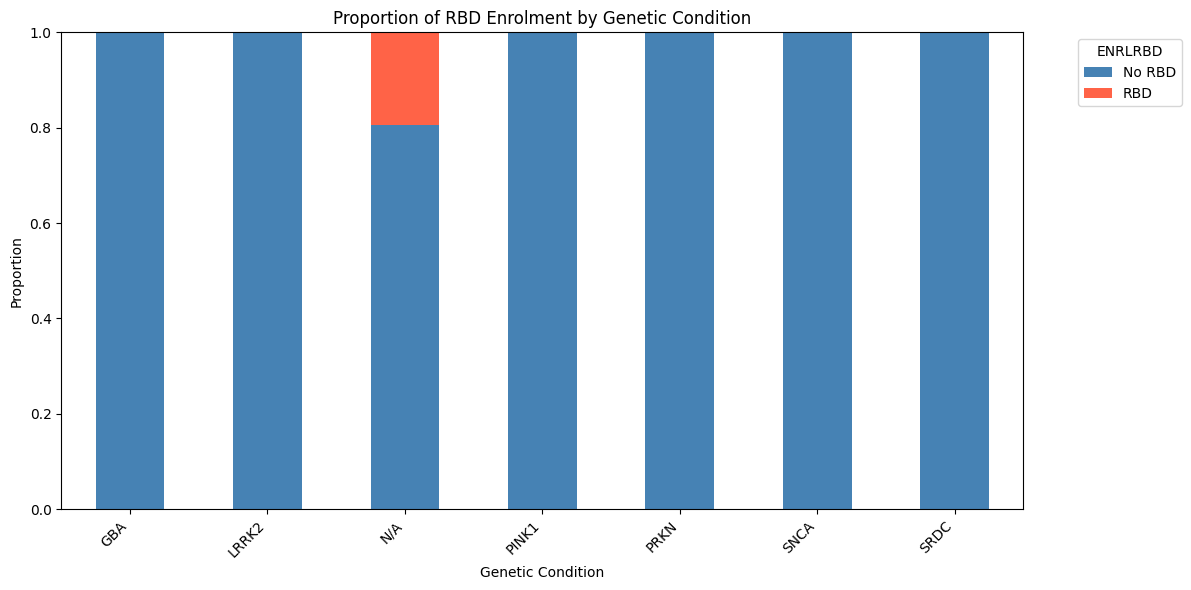

In [198]:
rbd_prop_df = (
    clean_fam_hist_df.groupby(['GEN_COND', 'ENRLRBD'])
    .size()
    .groupby(level=0)
    .transform(lambda x: x / x.sum())
    .unstack('ENRLRBD', fill_value=0)
    .rename(columns={0: 'No RBD', 1: 'RBD'})
)

ax = rbd_prop_df.plot(kind='bar', stacked=True, figsize=(12, 6), color=['steelblue', 'tomato'])
ax.set_title('Proportion of RBD Enrolment by Genetic Condition')
ax.set_xlabel('Genetic Condition')
ax.set_ylabel('Proportion')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='ENRLRBD', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### How are the study cohorts distributed across the genetic groups?

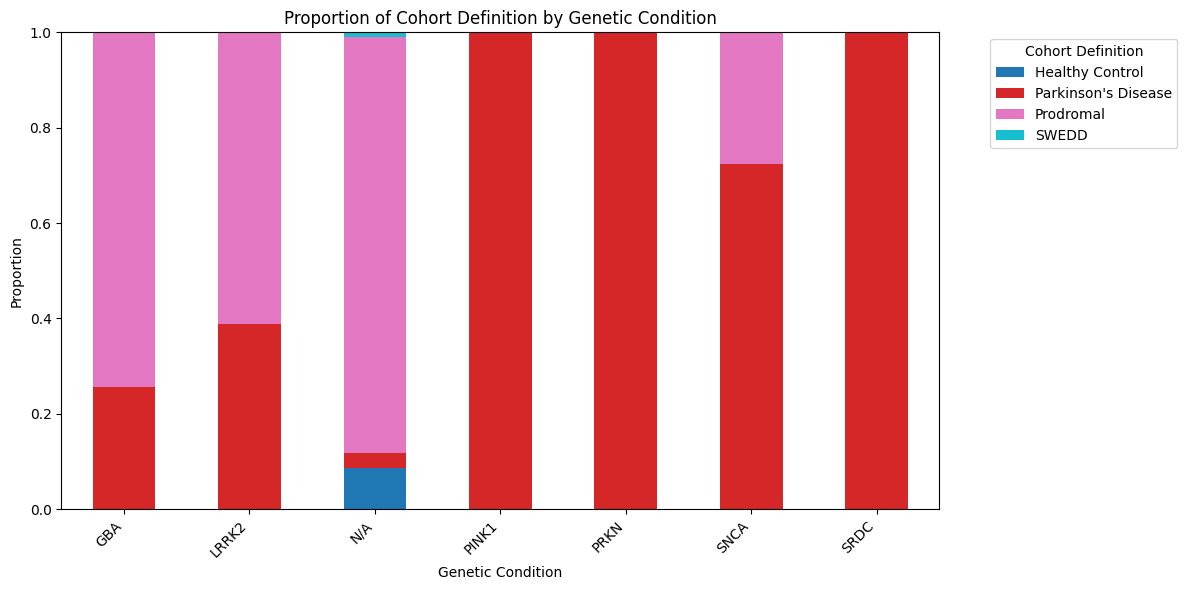

In [200]:
cohort_prop_df = (
    clean_fam_hist_df.groupby(['GEN_COND', 'COHORT_DEFINITION'])
    .size()
    .groupby(level=0)
    .transform(lambda x: x / x.sum())
    .unstack('COHORT_DEFINITION', fill_value=0)
)

ax = cohort_prop_df.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab10')
ax.set_title('Proportion of Cohort Definition by Genetic Condition')
ax.set_xlabel('Genetic Condition')
ax.set_ylabel('Proportion')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='Cohort Definition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

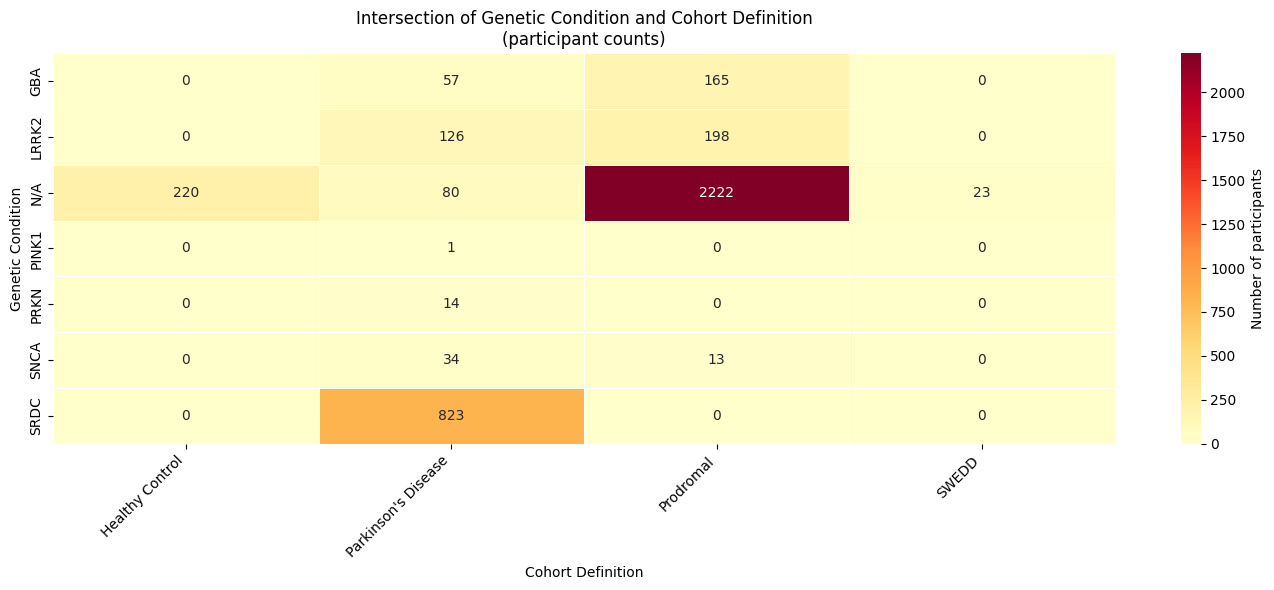

In [201]:
cross_tab = (
    clean_fam_hist_df.groupby(['GEN_COND', 'COHORT_DEFINITION'])
    .size()
    .unstack('COHORT_DEFINITION', fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    cross_tab,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Number of participants'}
)
ax.set_title('Intersection of Genetic Condition and Cohort Definition\n(participant counts)')
ax.set_xlabel('Cohort Definition')
ax.set_ylabel('Genetic Condition')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
depression
Vitamin D deficiency
constipation
bowel syndrome
